In [2]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [3]:
api_wikipedia=WikipediaAPIWrapper(top_k_results=5,doc_content_chars_max=500 )

wiki_tool=WikipediaQueryRun(api_wrapper=api_wikipedia)

In [4]:
print(wiki_tool.args)
print(wiki_tool.description,"\n")

query="Elon Musk"
print(wiki_tool.run(query))

{'query': {'description': 'query to look up on wikipedia', 'title': 'Query', 'type': 'string'}}
A wrapper around Wikipedia. Useful for when you need to answer general questions about people, places, companies, facts, historical events, or other subjects. Input should be a search query. 

Page: Elon Musk
Summary: Elon Reeve Musk ( EE-lon; born June 28, 1971) is a businessman. He is known for his leadership of Tesla, SpaceX, X (formerly Twitter), and the Department of Government Efficiency (DOGE). Musk has been considered the wealthiest person in the world since 2021; as of May 2025, Forbes estimates his net worth to be US$424.7 billion. 
Born to a wealthy family in Pretoria, South Africa, Musk emigrated in 1989 to Canada. He received bachelor's degrees from the University of Penn


In [5]:
from langchain_community.tools import YouTubeSearchTool
yt_tool=YouTubeSearchTool()

print(yt_tool.name)

print(yt_tool.run("krish naik"))

youtube_search
['https://www.youtube.com/watch?v=p4pHsuEf4Ms&pp=ygUKa3Jpc2ggbmFpaw%3D%3D', 'https://www.youtube.com/watch?v=JxgmHe2NyeY&pp=ygUKa3Jpc2ggbmFpaw%3D%3D']


In [ ]:
from dotenv import load_dotenv
load_dotenv
import os

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
print(os.getenv("GROQ_API_KEY"))

from langchain_community.tools.tavily_search import TavilySearchResults

TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")

tavily_tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

tavily_tool.invoke({"query":"what happend to FUTU stocks?"})


In [7]:
#if we use invoke we need to pass as dictionary
#need to pass docstring if we use decorater
from langchain.agents import tool

@tool
def multiply(a:int,b:int) -> int:
    """This is multiply function"""
    return(a*b)

# need to use invoke bcs we are using langchain tool , run is in older langchain
print(multiply.invoke({"a":113,"b":113}))

#since we are using Tool decaratior we can get the below manythings from that
print(multiply.name)
print(multiply.description)

12769
multiply
This is multiply function


In [8]:
def function1(input1):
    return input1+" from first function"
def function2(input2):
    return input2+" from second function"
def function3(input3):
    return input3+" from third function"


In [9]:
function1("arun")

'arun from first function'

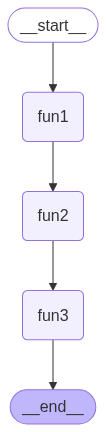

'hi this is kumar from first function from second function from third function'

In [10]:
from langgraph.graph import END, Graph
from IPython.display import display,Image


workflow = Graph()

workflow.add_node("fun1", function1)
workflow.add_node("fun2", function2)
workflow.add_node("fun3", function3)

workflow.set_entry_point("fun1")
workflow.add_edge("fun1", "fun2")
workflow.add_edge("fun2", "fun3")
workflow.set_finish_point("fun3")

# Compile the graph
app = workflow.compile()

# Visualize the graph (returns a PIL Image)

display(Image(app.get_graph().draw_mermaid_png()))

app.invoke("hi this is kumar")
# Invoke the graph with input
#result = app.invoke("this is sunny")
#print(result)  # Output from function3 after passing through all nodes


In [11]:
from langchain_groq import ChatGroq

model=ChatGroq(model="qwen-qwq-32B")

model.invoke("hi").content

'\n<think>\nOkay, the user said "hi". I should respond in a friendly way. Maybe say "Hello!" and ask how I can assist them today. Keep it simple and open-ended so they feel comfortable asking for help. Let me check if there are any guidelines I need to follow, but since it\'s just a greeting, a straightforward reply should be fine. Maybe add an emoji to keep it friendly. Alright, that\'s all.\n</think>\n\nHello! 😊 How can I assist you today?'

In [12]:
def llm(input):
    model=ChatGroq(model="qwen-qwq-32B")
    output=model.invoke(input)
    return output.content

In [13]:
# maintaing the sate we pass the LLM output to this
def token_counter(input):
    token=input.split()
    token_num=len(token)
    return f"total amount of token present {token_num}"

def naming(input):
    return f"Hi Arun the {input}"

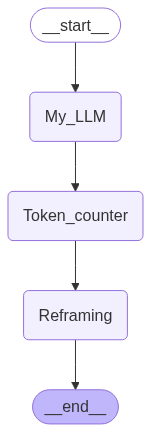

In [14]:
from langgraph.graph import END, Graph
workflow2=Graph()

#Assinig a token to the variable

workflow2.add_node("My_LLM",llm)
workflow2.add_node("Token_counter",token_counter)
workflow2.add_node("Reframing",naming)

workflow2.add_edge("My_LLM","Token_counter")
workflow2.add_edge("Token_counter","Reframing")

workflow2.set_entry_point("My_LLM")
workflow2.set_finish_point("Reframing")

app=workflow2.compile()
display(Image(app.get_graph().draw_mermaid_png()))

In [17]:

app.invoke("can you tell me about the india's capital?")

'Hi Arun the total amount of token present 1248'

In [19]:
for output in app.stream("an you tell me about the india's capital and its speciality?"):
    for key,value in output.items():
        print(f"here is the output from {key}")
        print(value)
        print("--------")
        print("/n")


here is the output from My_LLM

<think>
Okay, I need to explain India's capital and its speciality. Let's start with the basics. The capital of India is New Delhi. Wait, but isn't Delhi a bigger city? Maybe I should clarify that New Delhi is part of the larger National Capital Territory of Delhi. Right, so New Delhi is the official capital, while Delhi is the metropolitan area.

Now, about its specialties. First, its historical significance. I remember that New Delhi was built by the British during the British Raj, around 1911, and it became the capital in 1931, replacing Kolkata. That's an important point. It was designed by Edwin Lutyens and Herbert Baker, so the architecture there is a mix of British and Indian styles. Landmarks like India Gate, Rashtrapati Bhavan, and India Gate are key examples.

Then there's political importance. New Delhi is where all the government buildings are, like the Parliament, the President's residence, and the Supreme Court. That's part of its specialty